# Ensemble Convergence Analysis

This notebook analyzes how different realizations of the same task converge during training.

**Analyses:**
1. Distribution of minimum loss per task
2. Inner product of best stiffnesses (solution similarity)
3. Distribution of loss ratio (min/initial)
4. Attained vs target Poisson ratios scatter plot

In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import copy

# Add paths
sys.path.append('../ensemble_training')
sys.path.append('../instruments')

from task_generator import generate_task_config, get_all_task_configs
from config import N_TASKS, COMPRESSION_POOL, POISSON_POOL, N_NODES, BOUNDARY_MARGIN, FORCE_TYPE
from network_utils import create_auxetic_network, get_square_boundary_nodes
from elastic_network import ElasticNetwork
from training_functions_with_toggle import compute_poisson_ratio_single

# Set plot style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [3]:
# Configuration
DATA_DIR = Path('../data/auxetic_nets')
print(f"Data directory: {DATA_DIR}")
print(f"Exists: {DATA_DIR.exists()}")

Data directory: ../data/auxetic_nets
Exists: True


## Data Loading Utilities

In [4]:
def discover_tasks(data_dir):
    """Find all task directories in data_dir."""
    data_dir = Path(data_dir)
    tasks = []
    for d in sorted(data_dir.iterdir()):
        if d.is_dir() and d.name.startswith('task_'):
            task_seed = int(d.name.split('_')[1])
            tasks.append(task_seed)
    return tasks


def discover_realizations(task_seed, data_dir):
    """Find all completed realizations for a given task."""
    data_dir = Path(data_dir)
    task_dir = data_dir / f'task_{task_seed:02d}'
    realizations = []
    
    if not task_dir.exists():
        return realizations
    
    for d in sorted(task_dir.iterdir()):
        if d.is_dir() and d.name.startswith('realization_'):
            # Check if loss trajectory exists
            if (d / 'loss_trajectory.npy').exists():
                real_seed = int(d.name.split('_')[1])
                realizations.append(real_seed)
    
    return realizations


def load_trajectories(task_seed, realization_seed, data_dir):
    """Load loss and stiffness trajectories from .npy files."""
    data_dir = Path(data_dir)
    path = data_dir / f'task_{task_seed:02d}' / f'realization_{realization_seed:02d}'
    
    loss = np.load(path / 'loss_trajectory.npy')
    stiffness = np.load(path / 'stiffness_trajectory.npy')
    
    return loss, stiffness


def reconstruct_network_for_task(task_seed, n_nodes=N_NODES, boundary_margin=BOUNDARY_MARGIN):
    """
    Reconstruct the network for a given task using packing_seed = task_seed.
    
    Returns:
        network: ElasticNetwork object
        boundary_dict: dict with 'top', 'bottom', 'left', 'right' node indices
    """
    network, boundary_dict = create_auxetic_network(
        n_nodes=n_nodes,
        packing_seed=task_seed,
        boundary_margin=boundary_margin
    )
    return network, boundary_dict

In [5]:
# Discover available data
tasks = discover_tasks(DATA_DIR)
print(f"Found {len(tasks)} tasks: {tasks}")

for task in tasks:
    realizations = discover_realizations(task, DATA_DIR)
    config = generate_task_config(task)
    print(f"  Task {task}: {len(realizations)} realizations")
    print(f"    Compression strains: {config['compression_strains']}")
    print(f"    Target Poisson ratios: {config['target_poisson_ratios']}")

Found 6 tasks: [0, 1, 2, 3, 4, 5]
  Task 0: 21 realizations
    Compression strains: [-0.08, -0.03]
    Target Poisson ratios: [-0.25, -0.5]
  Task 1: 20 realizations
    Compression strains: [-0.09, -0.03]
    Target Poisson ratios: [-0.3, -0.5]
  Task 2: 20 realizations
    Compression strains: [-0.05, -0.02]
    Target Poisson ratios: [-0.1, -1.0]
  Task 3: 20 realizations
    Compression strains: [-0.06999999999999999, -0.03]
    Target Poisson ratios: [-0.1, -0.8]
  Task 4: 20 realizations
    Compression strains: [-0.04, -0.05]
    Target Poisson ratios: [-1.0, -0.3]
  Task 5: 11 realizations
    Compression strains: [-0.03, -0.05]
    Target Poisson ratios: [-1.0, -0.25]


## Load All Ensemble Data

In [ ]:
task_config

dict_keys(['task_seed', 'packing_seed', 'compression_strains', 'target_poisson_ratios'])

In [24]:
# Load all data
ensemble_data = {}

for task in tqdm(tasks, desc='Loading tasks'):
    realizations = discover_realizations(task, DATA_DIR)
    task_config = generate_task_config(task)

    print(f"\nLoading Task {task} with {len(realizations)} realizations")
    print(f"  Compression strains: {task_config['compression_strains']}")
    print(f"  Poisson ratios: {task_config['target_poisson_ratios']}")
    print(f"  Packing seeds: {task_config['packing_seed']}")
    
    task_data = {
        'config': task_config,
        'realizations': {}
    }
    
    for real in realizations:
        try:
            loss, stiffness = load_trajectories(task, real, DATA_DIR)
            task_data['realizations'][real] = {
                'loss': loss,
                'stiffness': stiffness,
                'min_loss': np.min(loss),
                'initial_loss': loss[0],
                'final_loss': loss[-1],
                'best_step': np.argmin(loss),
                'best_stiffness': stiffness[np.argmin(loss)]
            }
        except Exception as e:
            print(f"  Error loading task {task}, realization {real}: {e}")
    
    ensemble_data[task] = task_data

print(f"\nLoaded data for {len(ensemble_data)} tasks")

Loading tasks: 100%|██████████| 6/6 [00:00<00:00, 62.71it/s]


Loading Task 0 with 21 realizations
  Compression strains: [-0.08, -0.03]
  Poisson ratios: [-0.25, -0.5]
  Packing seeds: 0

Loading Task 1 with 20 realizations
  Compression strains: [-0.09, -0.03]
  Poisson ratios: [-0.3, -0.5]
  Packing seeds: 1

Loading Task 2 with 20 realizations
  Compression strains: [-0.05, -0.02]
  Poisson ratios: [-0.1, -1.0]
  Packing seeds: 2

Loading Task 3 with 20 realizations
  Compression strains: [-0.06999999999999999, -0.03]
  Poisson ratios: [-0.1, -0.8]
  Packing seeds: 3

Loading Task 4 with 20 realizations
  Compression strains: [-0.04, -0.05]
  Poisson ratios: [-1.0, -0.3]
  Packing seeds: 4

Loading Task 5 with 11 realizations
  Compression strains: [-0.03, -0.05]
  Poisson ratios: [-1.0, -0.25]
  Packing seeds: 5

Loaded data for 6 tasks


## Analysis 1: Distribution of Minimum Loss Per Task

In [7]:
# Collect minimum losses per task
min_losses_data = []

for task, task_data in ensemble_data.items():
    for real, real_data in task_data['realizations'].items():
        min_losses_data.append({
            'task': task,
            'realization': real,
            'min_loss': real_data['min_loss']
        })

df_min_loss = pd.DataFrame(min_losses_data)
print(f"Total realizations: {len(df_min_loss)}")
print(df_min_loss.groupby('task')['min_loss'].describe())

Total realizations: 112
      count      mean       std           min       25%       50%       75%  \
task                                                                          
0      17.0  0.001150  0.001827  1.430660e-07  0.000001  0.000073  0.001948   
1      19.0  0.000276  0.000863  9.854173e-08  0.000002  0.000017  0.000106   
2      19.0  0.167161  0.272541  5.687282e-03  0.027887  0.059110  0.092580   
3      20.0  0.083189  0.169783  4.952952e-05  0.023158  0.030982  0.040367   
4      20.0  0.091530  0.010883  6.580582e-02  0.085377  0.095941  0.100571   
5      10.0  0.200846  0.303956  3.516279e-02  0.051162  0.061176  0.080192   

           max  
task            
0     0.006810  
1     0.003799  
2     0.828377  
3     0.625560  
4     0.104100  
5     0.821180  


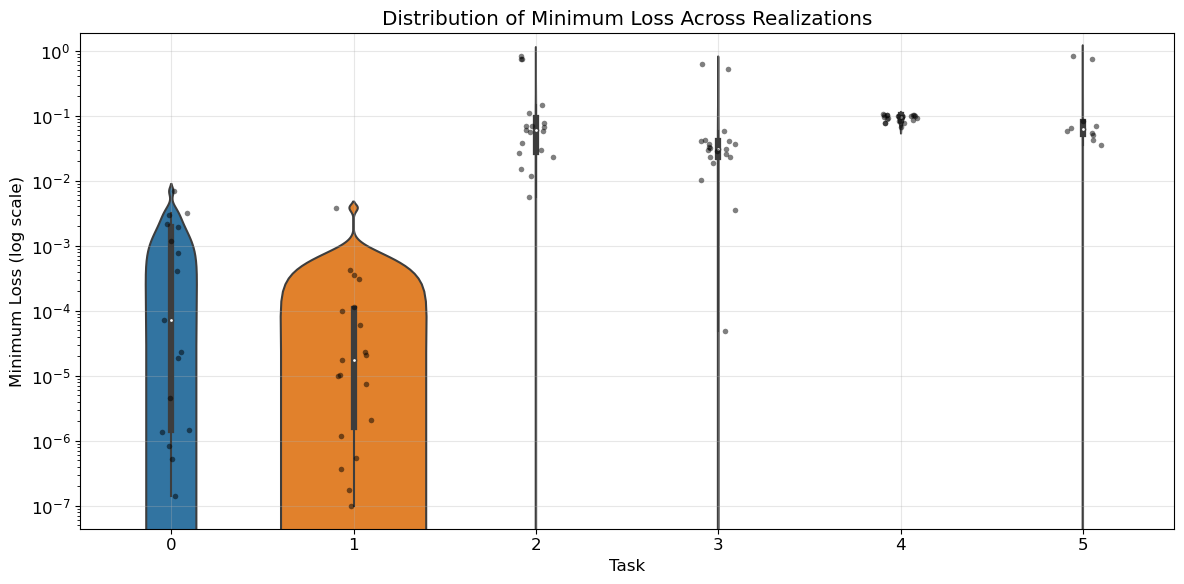

In [8]:
# Violin plot of minimum loss distribution per task
fig, ax = plt.subplots(figsize=(12, 6))

sns.violinplot(data=df_min_loss, x='task', y='min_loss', ax=ax, inner='box')
sns.stripplot(data=df_min_loss, x='task', y='min_loss', ax=ax, 
              color='black', alpha=0.5, size=4)

ax.set_yscale('log')
ax.set_xlabel('Task')
ax.set_ylabel('Minimum Loss (log scale)')
ax.set_title('Distribution of Minimum Loss Across Realizations')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Analysis 2: Inner Product of Best Stiffnesses

In [9]:
def compute_stiffness_similarity_matrix(task_data):
    """
    Compute pairwise cosine similarity of best stiffnesses for a task.
    
    Returns:
        similarity_matrix: (n_realizations, n_realizations) matrix
        realization_ids: list of realization indices
    """
    realizations = task_data['realizations']
    realization_ids = sorted(realizations.keys())
    n_real = len(realization_ids)
    
    # Collect best stiffnesses
    stiffnesses = np.array([realizations[r]['best_stiffness'] for r in realization_ids])
    
    # Normalize
    norms = np.linalg.norm(stiffnesses, axis=1, keepdims=True)
    normalized = stiffnesses / (norms + 1e-16)
    
    # Compute cosine similarity
    similarity_matrix = normalized @ normalized.T
    
    return similarity_matrix, realization_ids

In [10]:
# Compute similarity matrices for all tasks
similarity_data = {}

for task, task_data in ensemble_data.items():
    if len(task_data['realizations']) >= 2:
        sim_matrix, real_ids = compute_stiffness_similarity_matrix(task_data)
        similarity_data[task] = {
            'matrix': sim_matrix,
            'realization_ids': real_ids
        }

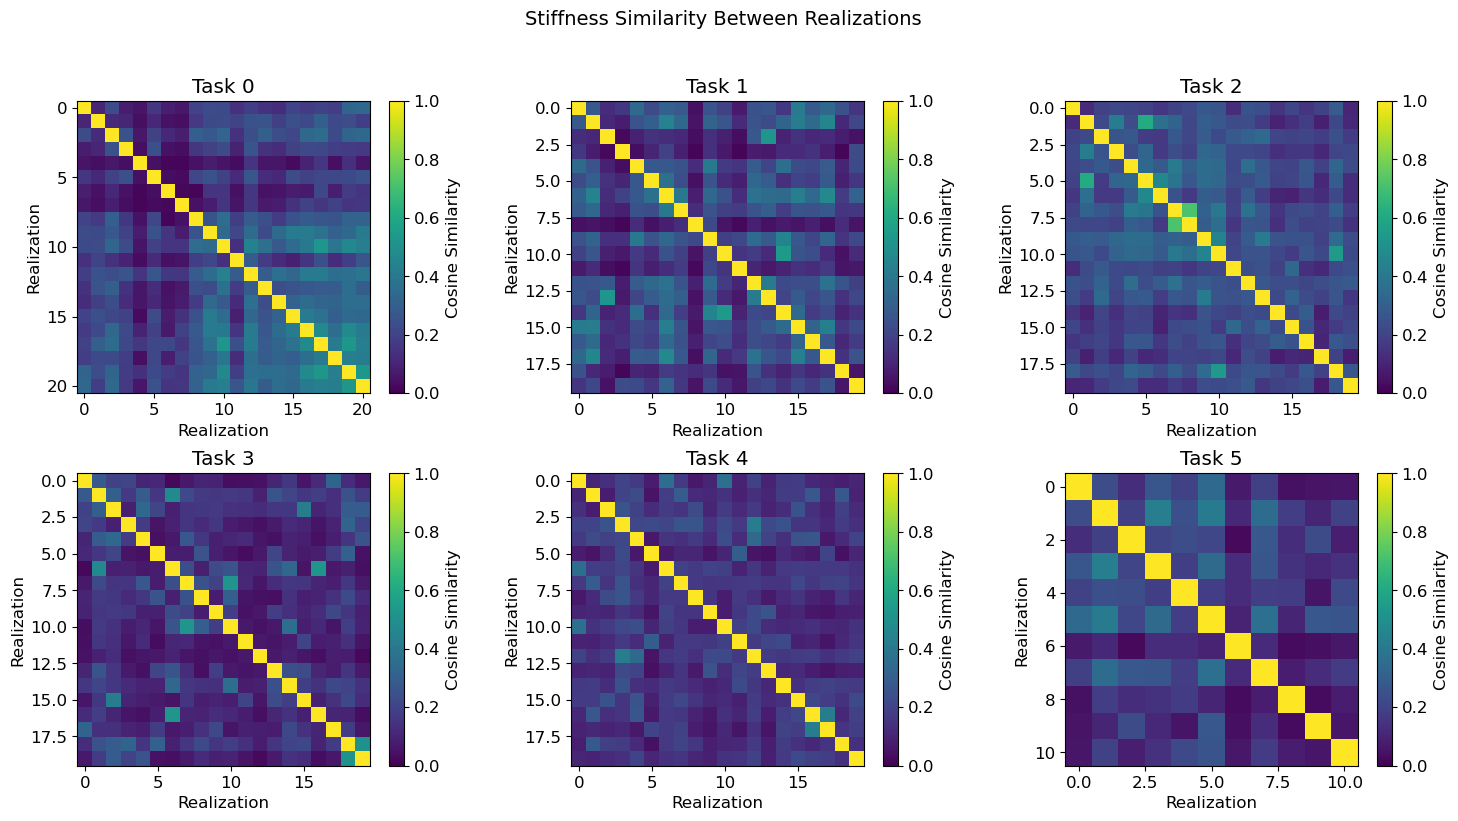

In [11]:
# Plot similarity heatmaps for each task
n_tasks_plot = len(similarity_data)
ncols = min(3, n_tasks_plot)
nrows = (n_tasks_plot + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
if n_tasks_plot == 1:
    axes = np.array([axes])
axes = axes.flatten()

for idx, (task, sim_data) in enumerate(similarity_data.items()):
    ax = axes[idx]
    im = ax.imshow(sim_data['matrix'], vmin=0, vmax=1, cmap='viridis')
    ax.set_title(f'Task {task}')
    ax.set_xlabel('Realization')
    ax.set_ylabel('Realization')
    plt.colorbar(im, ax=ax, label='Cosine Similarity')

# Hide unused axes
for idx in range(n_tasks_plot, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Stiffness Similarity Between Realizations', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

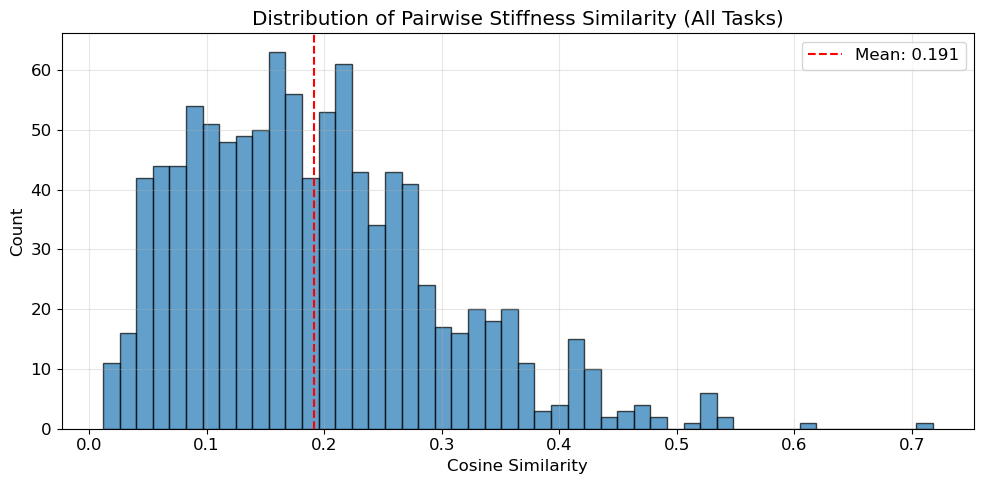


Summary of off-diagonal similarities:
count    1025.000000
mean        0.191296
std         0.105618
min         0.011956
25%         0.109302
50%         0.177941
75%         0.254216
max         0.717382
Name: similarity, dtype: float64


In [13]:
# Collect off-diagonal similarity values across all tasks
off_diagonal_similarities = []

for task, sim_data in similarity_data.items():
    matrix = sim_data['matrix']
    n = matrix.shape[0]
    # Extract upper triangle (excluding diagonal)
    for i in range(n):
        for j in range(i+1, n):
            off_diagonal_similarities.append({
                'task': task,
                'similarity': matrix[i, j]
            })

df_similarity = pd.DataFrame(off_diagonal_similarities)

# Histogram of similarities
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_similarity['similarity'], bins=50, edgecolor='black', alpha=0.7)
ax.axvline(df_similarity['similarity'].mean(), color='red', linestyle='--', 
           label=f'Mean: {df_similarity["similarity"].mean():.3f}')
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Count')
ax.set_title('Distribution of Pairwise Stiffness Similarity (All Tasks)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nSummary of off-diagonal similarities:")
print(df_similarity['similarity'].describe())

## Analysis 3: Distribution of Loss Ratio (min/initial)

In [14]:
# Collect loss ratios
loss_ratio_data = []

for task, task_data in ensemble_data.items():
    for real, real_data in task_data['realizations'].items():
        ratio = real_data['min_loss'] / real_data['initial_loss']
        loss_ratio_data.append({
            'task': task,
            'realization': real,
            'loss_ratio': ratio,
            'initial_loss': real_data['initial_loss'],
            'min_loss': real_data['min_loss']
        })

df_loss_ratio = pd.DataFrame(loss_ratio_data)
print("Loss ratio (min/initial) statistics:")
print(df_loss_ratio.groupby('task')['loss_ratio'].describe())

Loss ratio (min/initial) statistics:
      count      mean       std           min       25%       50%       75%  \
task                                                                          
0      17.0  0.002461  0.003899  4.379406e-07  0.000003  0.000131  0.004324   
1      19.0  0.000577  0.001704  2.768143e-07  0.000004  0.000046  0.000300   
2      19.0  0.214690  0.352005  7.552941e-03  0.034246  0.071816  0.119208   
3      20.0  0.143103  0.293944  6.863229e-05  0.038825  0.055461  0.066198   
4      20.0  0.116543  0.027849  7.276954e-02  0.099805  0.114336  0.126653   
5      10.0  0.263310  0.390176  4.910696e-02  0.057997  0.070076  0.159257   

           max  
task            
0     0.014138  
1     0.007489  
2     1.000000  
3     1.000000  
4     0.171808  
5     1.000000  


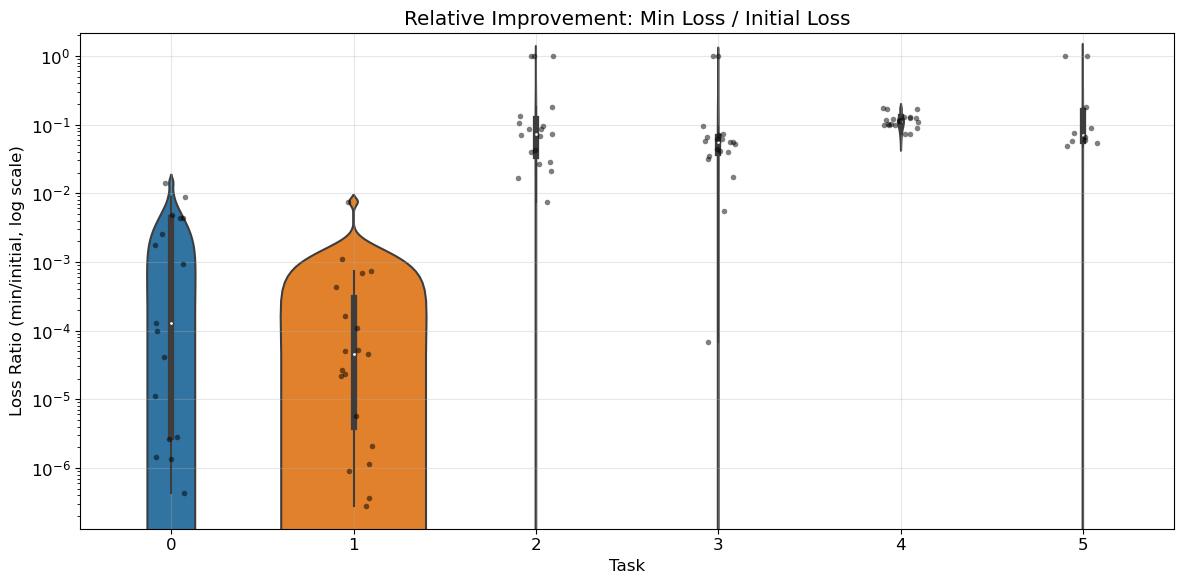

In [15]:
# Violin plot of loss ratio distribution per task
fig, ax = plt.subplots(figsize=(12, 6))

sns.violinplot(data=df_loss_ratio, x='task', y='loss_ratio', ax=ax, inner='box')
sns.stripplot(data=df_loss_ratio, x='task', y='loss_ratio', ax=ax, 
              color='black', alpha=0.5, size=4)

ax.set_yscale('log')
ax.set_xlabel('Task')
ax.set_ylabel('Loss Ratio (min/initial, log scale)')
ax.set_title('Relative Improvement: Min Loss / Initial Loss')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Analysis 4: Attained vs Target Poisson Ratios

In [16]:
def compute_attained_poisson_ratios(task_seed, best_stiffness, data_dir=DATA_DIR,
                                    n_strain_steps=20, force_type=FORCE_TYPE):
    """
    Compute attained Poisson ratios for a network with given stiffnesses.
    
    Returns:
        attained_poissons: list of 2 floats (one per subtask)
        target_poissons: list of 2 floats
        compression_strains: list of 2 floats
    """
    # Get task configuration
    task_config = generate_task_config(task_seed)
    compression_strains = task_config['compression_strains']
    target_poissons = task_config['target_poisson_ratios']
    
    # Reconstruct network
    network, boundary_dict = reconstruct_network_for_task(task_seed)
    
    # Set the trained stiffnesses
    network.stiffnesses = np.array(best_stiffness)
    
    # Get boundary nodes
    top_nodes = boundary_dict['top']
    bottom_nodes = boundary_dict['bottom']
    left_nodes = boundary_dict['left']
    right_nodes = boundary_dict['right']
    
    # Compute attained Poisson ratio for each compression strain
    attained_poissons = []
    for cs in compression_strains:
        pr = compute_poisson_ratio_single(
            copy.deepcopy(network), 
            top_nodes, bottom_nodes, left_nodes, right_nodes,
            cs, n_strain_steps=n_strain_steps, force_type=force_type
        )
        attained_poissons.append(pr)
    
    return attained_poissons, target_poissons, compression_strains

In [17]:
# Compute attained Poisson ratios for all realizations
# NOTE: This is computationally expensive - you may want to limit the number of realizations

MAX_REALIZATIONS_PER_TASK = 5  # Set to None to process all

poisson_scatter_data = []

for task, task_data in tqdm(ensemble_data.items(), desc='Computing Poisson ratios'):
    realizations = list(task_data['realizations'].keys())
    if MAX_REALIZATIONS_PER_TASK is not None:
        realizations = realizations[:MAX_REALIZATIONS_PER_TASK]
    
    for real in realizations:
        real_data = task_data['realizations'][real]
        best_stiffness = real_data['best_stiffness']
        
        try:
            attained, target, cs = compute_attained_poisson_ratios(
                task, best_stiffness
            )
            
            # Add both subtasks as separate data points
            for subtask_idx in range(2):
                poisson_scatter_data.append({
                    'task': task,
                    'realization': real,
                    'subtask': subtask_idx,
                    'compression_strain': cs[subtask_idx],
                    'target_poisson': target[subtask_idx],
                    'attained_poisson': attained[subtask_idx],
                    'min_loss': real_data['min_loss']
                })
        except Exception as e:
            print(f"  Error computing Poisson for task {task}, real {real}: {e}")

df_poisson = pd.DataFrame(poisson_scatter_data)
print(f"\nComputed Poisson ratios for {len(df_poisson)} data points")

progress: 100%|##########| 1000.00/1000.00 [00:03<00:00] ?it/s]
progress: 100%|##########| 1000.00/1000.00 [00:03<00:00]
progress: 100%|##########| 1000.00/1000.00 [00:03<00:00]
progress: 100%|##########| 1000.00/1000.00 [00:03<00:00]
progress: 100%|##########| 1000.00/1000.00 [00:03<00:00]
progress: 100%|##########| 1000.00/1000.00 [00:02<00:00]:41, 20.32s/it]
progress: 100%|##########| 1000.00/1000.00 [00:02<00:00]
progress: 100%|##########| 1000.00/1000.00 [00:02<00:00]
progress: 100%|##########| 1000.00/1000.00 [00:02<00:00]
progress: 100%|##########| 1000.00/1000.00 [00:02<00:00]
progress: 100%|##########| 1000.00/1000.00 [00:04<00:00]:10, 17.71s/it]
progress: 100%|##########| 1000.00/1000.00 [00:04<00:00]
progress: 100%|##########| 1000.00/1000.00 [00:04<00:00]
progress: 100%|##########| 1000.00/1000.00 [00:04<00:00]
progress: 100%|##########| 1000.00/1000.00 [00:04<00:00]
progress: 100%|##########| 1000.00/1000.00 [00:04<00:00]:00, 20.12s/it]
progress: 100%|##########| 1000.00/1


Computed Poisson ratios for 60 data points


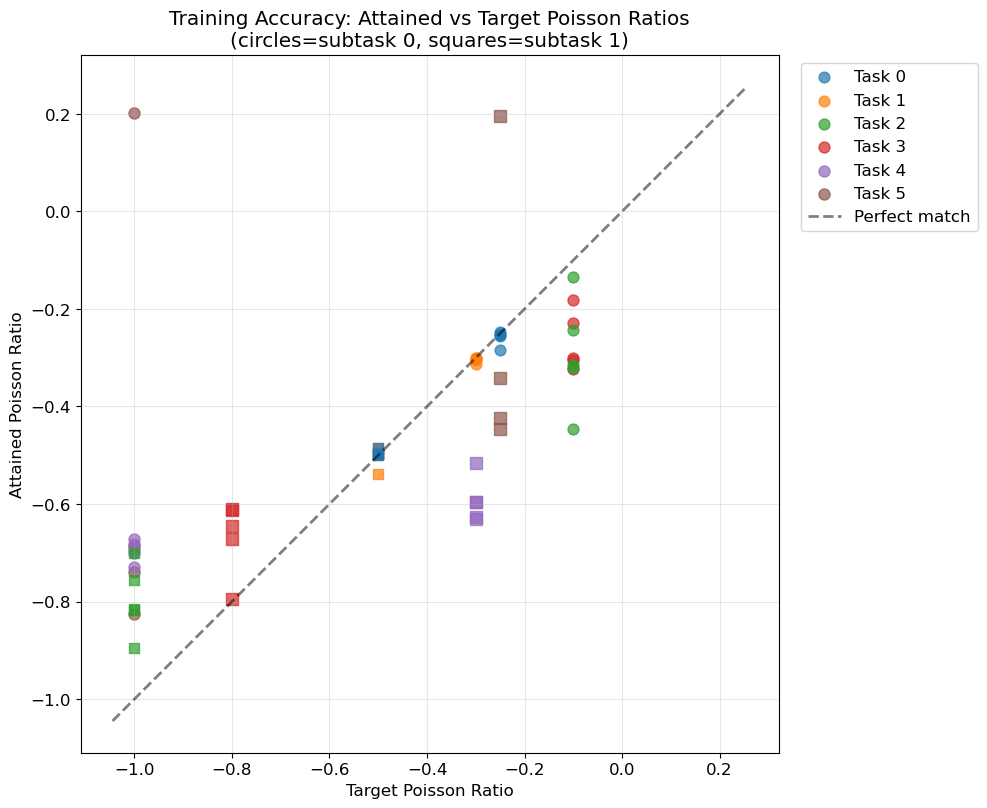

In [30]:
# Scatter plot: attained vs target Poisson ratios
fig, ax = plt.subplots(figsize=(10, 10))

# Plot each task with different color
colors = plt.cm.tab10.colors
markers = ['o', 's']  # Circle for subtask 0, square for subtask 1

for task_idx, task in enumerate(df_poisson['task'].unique()):
    subset = df_poisson[df_poisson['task'] == task]
    color = colors[task_idx % len(colors)]
    
    for subtask in [0, 1]:
        sub_subset = subset[subset['subtask'] == subtask]
        label = f'Task {task}, Subtask {subtask}' if subtask == 0 else None
        ax.scatter(sub_subset['target_poisson'], sub_subset['attained_poisson'],
                   c=[color], marker=markers[subtask], alpha=0.7, s=task_idx+60,
                   label=f'Task {task}' if subtask == 0 else None, zorder=-task_idx)

# Diagonal line (perfect match)
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'k--', alpha=0.5, linewidth=2, label='Perfect match')

ax.set_xlabel('Target Poisson Ratio')
ax.set_ylabel('Attained Poisson Ratio')
ax.set_title('Training Accuracy: Attained vs Target Poisson Ratios\n(circles=subtask 0, squares=subtask 1)')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

In [19]:
# Compute error statistics
df_poisson['error'] = df_poisson['attained_poisson'] - df_poisson['target_poisson']
df_poisson['abs_error'] = np.abs(df_poisson['error'])
df_poisson['relative_error'] = df_poisson['abs_error'] / np.abs(df_poisson['target_poisson'])

print("Error statistics:")
print(df_poisson[['error', 'abs_error', 'relative_error']].describe())

print("\nMean absolute error by task:")
print(df_poisson.groupby('task')['abs_error'].mean())

Error statistics:
           error  abs_error  relative_error
count  58.000000  58.000000       58.000000
mean    0.031320   0.163583        0.556773
std     0.247747   0.187478        0.762552
min    -0.346771   0.000339        0.000678
25%    -0.119272   0.006566        0.018122
50%     0.000389   0.164191        0.241249
75%     0.180150   0.257082        0.815083
max     1.201421   1.201421        3.467711

Mean absolute error by task:
task
0    0.007277
1    0.008772
2    0.197692
3    0.150679
4    0.298849
5    0.356892
Name: abs_error, dtype: float64


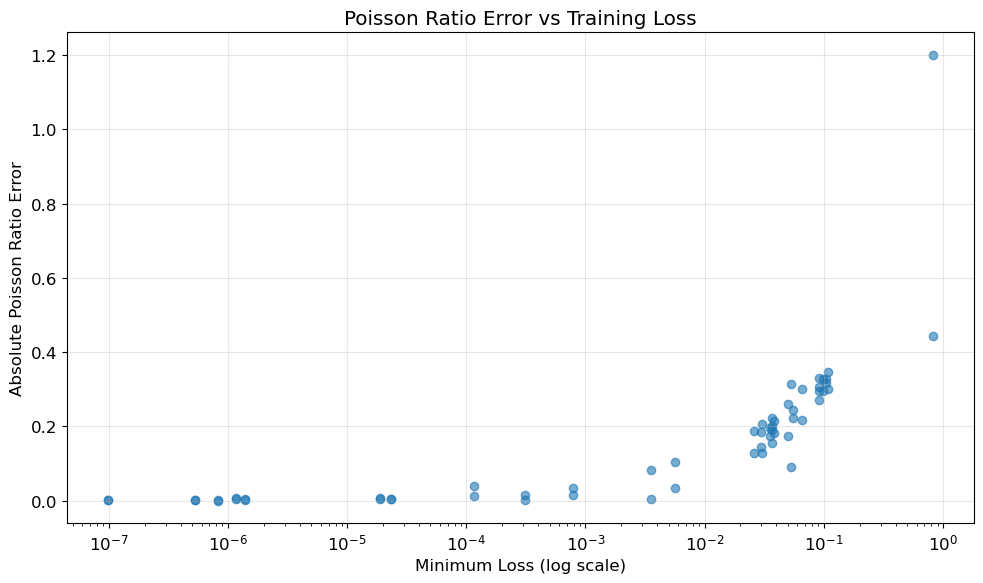

In [20]:
# Error vs min_loss scatter
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df_poisson['min_loss'], df_poisson['abs_error'], alpha=0.6)
ax.set_xscale('log')
ax.set_xlabel('Minimum Loss (log scale)')
ax.set_ylabel('Absolute Poisson Ratio Error')
ax.set_title('Poisson Ratio Error vs Training Loss')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary Statistics

In [21]:
print("="*60)
print("ENSEMBLE CONVERGENCE SUMMARY")
print("="*60)

print(f"\nTotal tasks analyzed: {len(ensemble_data)}")
total_realizations = sum(len(td['realizations']) for td in ensemble_data.values())
print(f"Total realizations: {total_realizations}")

print(f"\nMinimum loss statistics (across all realizations):")
all_min_losses = [rd['min_loss'] for td in ensemble_data.values() for rd in td['realizations'].values()]
print(f"  Mean: {np.mean(all_min_losses):.4e}")
print(f"  Median: {np.median(all_min_losses):.4e}")
print(f"  Min: {np.min(all_min_losses):.4e}")
print(f"  Max: {np.max(all_min_losses):.4e}")

print(f"\nStiffness similarity (off-diagonal):")
print(f"  Mean: {df_similarity['similarity'].mean():.4f}")
print(f"  Std: {df_similarity['similarity'].std():.4f}")

if len(df_poisson) > 0:
    print(f"\nPoisson ratio accuracy:")
    print(f"  Mean absolute error: {df_poisson['abs_error'].mean():.4f}")
    print(f"  Mean relative error: {df_poisson['relative_error'].mean():.2%}")

print("="*60)

ENSEMBLE CONVERGENCE SUMMARY

Total tasks analyzed: 6
Total realizations: 112

Minimum loss statistics (across all realizations):
  Mean: nan
  Median: nan
  Min: nan
  Max: nan

Stiffness similarity (off-diagonal):
  Mean: 0.1913
  Std: 0.1056

Poisson ratio accuracy:
  Mean absolute error: 0.1636
  Mean relative error: 55.68%
